In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
cali = fetch_california_housing()

In [21]:
cali.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [22]:
print(cali.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [23]:
cali.target_names

['MedHouseVal']

In [24]:
cali.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [25]:
dataset = pd.DataFrame(cali.data, columns=cali.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [30]:
dataset["Price"]=cali.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Divide the Dataset based on Independent and Dependent Feature
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [41]:
## Train and Test Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [42]:
## Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
## Train Simple Linear Regression
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train,y_train)

print("Slope or coeffient ",regressor.coef_)
print("Intercept: ",regressor.intercept_)


Slope or coeffient  [ 8.46603472e-01  1.20333548e-01 -2.98800785e-01  3.47243173e-01
 -8.81413334e-05 -4.17242067e-02 -8.94420371e-01 -8.70401317e-01]
Intercept:  2.066636204801853


In [44]:
y_pred_test = regressor.predict(X_test)
y_pred_test,y_test

(array([0.72563462, 1.76650223, 2.70545812, ..., 1.25803135, 1.66673014,
        2.25826279], shape=(6812,)),
 20046    0.47700
 3024     0.45800
 15663    5.00001
 20484    2.18600
 9814     2.78000
           ...   
 15316    1.66100
 14772    0.93600
 12870    1.07000
 13476    1.30700
 16123    3.07100
 Name: Price, Length: 6812, dtype: float64)

In [45]:
# Performance Metrics
## MAE,MSE,RMSE
### R square and adjusted R square

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Square Error", mse)
print("Root Mean Square Error", rmse)


Mean Absolute Error: 0.5295710106684453
Mean Square Error 0.536968654337246
Root Mean Square Error 0.7327814505957735


In [46]:
## Accuracy of Model

from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred_test)
print("R2 Score:", score)

R2 Score: 0.5970494128783952


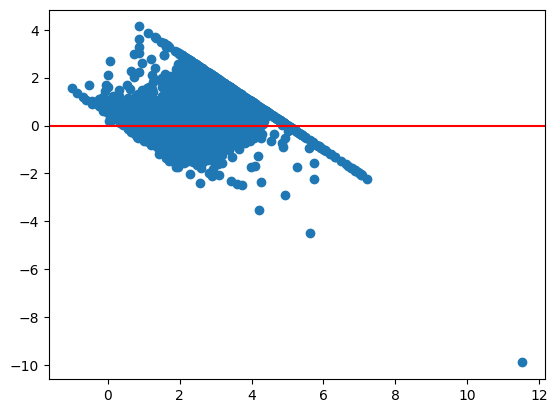

In [47]:
## Residuals
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.axhline(y=0, color='r')

In [48]:
# Plicking the Model

import pickle

pickle.dump(regressor, open('B:/SELF_LEARNING/artifacts/mlr_model.pkl','wb'))
